In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

/home/ssuarez/tutorials/pytorch_tutorial/.env/lib/python3.9/site-packages/torch/autograd/__init__.py:394: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11050). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  result = Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch [0/30000], Loss: 40.72529602050781
Epoch [1000/30000], Loss: 1.0007779598236084
Epoch [2000/30000], Loss: 0.9993214011192322
Epoch [3000/30000], Loss: 0.9982527494430542
Epoch [4000/30000], Loss: 0.9973375201225281
Epoch [5000/30000], Loss: 0.9947749972343445
Epoch [6000/30000], Loss: 0.9831652641296387
Epoch [7000/30000], Loss: 0.9446743130683899
Epoch [8000/30000], Loss: 0.9179882407188416
Epoch [9000/30000], Loss: 0.7229440212249756
Epoch [10000/30000], Loss: 0.28125107288360596
Epoch [11000/30000], Loss: 0.04319068789482117
Epoch [12000/30000], Loss: 0.004154045134782791
Epoch [13000/30000], Loss: 0.0005801235092803836
Epoch [14000/30000], Loss: 0.0035217106342315674
Epoch [15000/30000], Loss: 2.375832264078781e-05
Epoch [16000/30000], Loss: 2.734459485509433e-05
Epoch [17000/30000], Loss: 2.9217875635367818e-05
Epoch [18000/30000], Loss: 0.01102333702147007
Epoch [19000/30000], Loss: 8.744158549234271e-06
Epoch [20000/30000], Loss: 8.561847607779782e-06
Epoch [21000/30000], 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


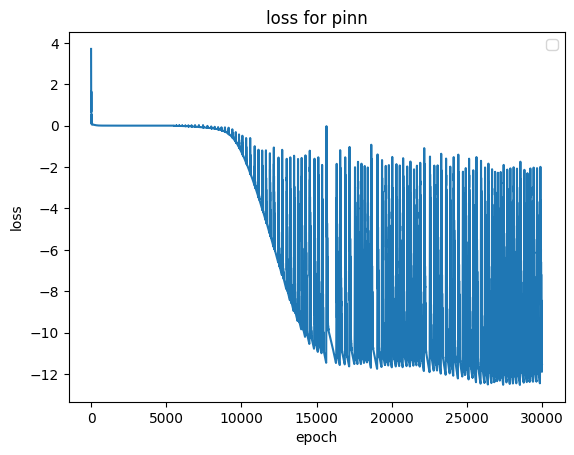

In [2]:


# parameters
ZETTA = 0.2
W = 10

# initial conditions
X0 = 1
X_T_0 = 0

# Define the PINN model
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 50),   # Input layer with 1 feature
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 50),    # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 50),    # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 1),    # Output layer for v(t)
        )

    def forward(self, t):
        return self.net(t)

# Define the Poisson equation loss function
def damped_oscillatior_loss(model, t):
    x = model(t)
    x_t = torch.autograd.grad(x, t, grad_outputs=torch.ones_like(x), create_graph=True)[0]
    x_tt = torch.autograd.grad(x_t, t, grad_outputs=torch.ones_like(x_t), create_graph=True)[0]
    f = (x_tt + (2*ZETTA*W)*x_t + (W**2)*x)**2  # Poisson equation: u_xx = 1
    t_0 = torch.tensor([0.0], requires_grad=True)
    x_0 = model(t_0)
    initial_conditions = (x_0 - X0)**2
    x_t_0 = torch.autograd.grad(x_0, t_0, grad_outputs=torch.ones_like(x_0), create_graph=True)[0]
    initial_conditions_der = (x_t_0 - X_T_0)**2
    return torch.mean(f) + torch.mean(initial_conditions) + torch.mean(initial_conditions_der)

# Training data
t = 2*torch.rand(100, 1)  # Randomly sampled points in [0, 1]
t.requires_grad = True

# Create PINN model
model = PINN()

optimizer = optim.Adam(params=[{'params': model.parameters()}, {'params': t}], lr=1e-4)

# loss tracking
losses = []

# Training loop
epochs = 30000
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Compute the loss
    loss = damped_oscillatior_loss(model, t)
    
    # Backpropagation
    loss.backward()
    losses.append(torch.log(loss).item())
    optimizer.step()
    
    if epoch % 1000 == 0:
        print(f"Epoch [{epoch}/{epochs}], Loss: {loss.item()}")


import matplotlib.pyplot as plt
plt.figure()
plt.plot(losses)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('loss for pinn')
plt.legend()
plt.show()

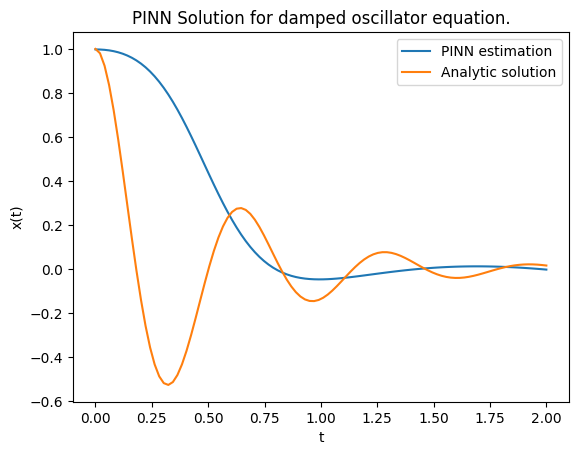

In [3]:
# Test the model
t_test = 2*torch.linspace(0, 1, 100).reshape(-1, 1)
x_test = model(t_test)
root = torch.sqrt(torch.tensor([ZETTA**2 - 1], dtype=torch.cfloat))
x_real = X0*torch.exp(-W*ZETTA*t_test)*(torch.cosh(W*root*t_test) + (ZETTA/root)*torch.sinh(W*root*t_test))
x_real = x_real.real

# Plot the results
import matplotlib.pyplot as plt
plt.figure()
plt.plot(t_test.detach().numpy(), x_test.detach().numpy(), label="PINN estimation")
plt.plot(t_test.detach().numpy(), x_real.detach().numpy(), label="Analytic solution")
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('PINN Solution for damped oscillator equation.')
plt.legend()
plt.show()